Importamos Pandas para analizar y manipular los datos <br>
Matplotlib para realizar graficos <br>

### Cuantos logs hay en total
hay un total de 5795 logs

In [259]:
%matplotlib inline

import pandas as pd
import matplotlib.pyplot as plt

print("librerias importadas")

librerias importadas


In [260]:
ruta = "logs/server_logs.csv"
df = pd.read_csv(ruta)

print("lectura correcta de los archivos CSV")
print(f"Hay un total de {len(df)} logs")


lectura correcta de los archivos CSV
Hay un total de 5795 logs


### Que nivel de severidad es mas frecuente entre los logs?<br>
La severidad INFO representa la mayoría de los logs (3542 de 5795), <br>
lo que sugiere que el sistema opera normalmente la mayor parte del tiempo.

In [261]:
print("Cantidad de valores")
df["severity"].value_counts().head()

Cantidad de valores


severity
INFO        3542
WARN        1358
ERROR        775
CRITICAL     120
Name: count, dtype: int64

### Que servicio genera mas logs y cual genera menos logs
El servicio api-gateway es el más activo con 1509 logs, <br>
mientras que notification-service es el menos activo con 645 logs.

In [262]:
print("SERVICIO POR LOGS")
servicio = df["service_name"].value_counts()

print(f"El servicio con mas logs es: {servicio.idxmax()} : {servicio.max()}")
print(f"El servicio con menos logs es: {servicio.idxmin()} : {servicio.min()}")


SERVICIO POR LOGS
El servicio con mas logs es: api-gateway : 1509
El servicio con menos logs es: notification-service : 645


### Cual es el mensage mas repetido?
El mensaje mas repetido es Health chech OK, indicando que la auto evaluacion del sistema designo que no habia errores la mayor parte del tiempo

In [263]:
print("Mensaje por mayor cantidad de logs")
print(df["message"]. value_counts().head(5))

Mensaje por mayor cantidad de logs
message
Health check OK                                   1196
Background job completed                          1185
Request completed                                 1161
Order creation failed - inventory lock timeout     197
Rate limit nearing threshold                       193
Name: count, dtype: int64


### Cual es Mensaje mas malo?
El mensaje mas malo (bad event) es Order creation failed - inventory lock timeout con un total de 197 repeticiones, lo que indica que el sistema necesita hacer una correccion 

In [264]:
severidad = df["severity"].isin(["ERROR","CRITICAL"])
status = df["status_code"] >= 500
bad_event = severidad | status

bad_column = df[bad_event]
bad_mensaje = bad_column["message"].value_counts()
print(f"El bad event mas repetido es: \n{bad_mensaje.head(1)}")

El bad event mas repetido es: 
message
Order creation failed - inventory lock timeout    197
Name: count, dtype: int64


### Deteccion del momento critico 
Generar una tabla (top 5) con: <br>
window_start <br>
total_events <br>
bad_events <br>
bad_rate Seleccionar el momento crítico (top 1 por regla). <br>


In [265]:
# 1. Convertir timestamp
df['timestamp_event'] = pd.to_datetime(df['timestamp_event'])

# 2. Máscaras y columna is_bad 
mask_severidad = df['severity'].isin(['ERROR', 'CRITICAL'])
mask_status = df['status_code'] >= 500
df['is_bad'] = mask_severidad | mask_status

# 3. Agrupar con Grouper + agg 
agrupar_por_tiempo = pd.Grouper(key='timestamp_event', freq='5min') 
tabla_eventos = (
    df.groupby(agrupar_por_tiempo).agg(
        total_events=('timestamp_event', 'count'),
        bad_events=('is_bad', 'sum')
    ).reset_index()
)

# 4. Calcular bad_rate
tabla_eventos['bad_rate'] = (
    tabla_eventos['bad_events'] / tabla_eventos['total_events']
)

# 5. Filtro mínimo de eventos 
tabla_filtrada = tabla_eventos.loc[
    tabla_eventos['total_events'] >= 20
]

# 6. Top 5
tabla_top5 = (
    tabla_filtrada
    .sort_values('bad_rate', ascending=False)
    .head(5)
)

# 7. Imprimir top 5 con formato 
print("\nTop 5 Ventanas Críticas:")
print(tabla_top5.to_string(index=False))

# 8. Momento crítico 
momento_critico = tabla_top5.iloc[0]
print(f"\nMomento Crítico:")
print(f"  Inicio:        {momento_critico['timestamp_event']}")
print(f"  Total eventos: {int(momento_critico['total_events'])}")
print(f"  Eventos malos: {int(momento_critico['bad_events'])}")
print(f"  Bad rate:      {momento_critico['bad_rate']:0}")


Top 5 Ventanas Críticas:
          timestamp_event  total_events  bad_events  bad_rate
2026-01-10 11:10:00+00:00           189         110  0.582011
2026-01-10 11:15:00+00:00           228         129  0.565789
2026-01-10 11:20:00+00:00           111          59  0.531532
2026-01-11 14:35:00+00:00           255         117  0.458824
2026-01-11 14:30:00+00:00           156          68  0.435897

Momento Crítico:
  Inicio:        2026-01-10 11:10:00+00:00
  Total eventos: 189
  Eventos malos: 110
  Bad rate:      0.582010582010582


### Diagnostico dentro del momento critico
**Dentro de esa ventana (top 1), generar:**<br>
Tabla: bad events por service_name (ranking) <br>
Tabla: top 5 message en bad events <br>
Tabla: top 5 endpoint más comprometidos <br>
**Elegí 1 criterio y declaralo explícitamente:** <br>
Por cantidad de bad events <br>
Por cantidad de status_code >= 500 <br>
Por mayor latency_ms promedio (Nada avanzado. Solo promedio si elegís latencia.) <br>

In [266]:
# CRITERIO: Por cantidad de status_code >= 500

# Filtrar ventana crítica
inicio_ventana = momento_critico['timestamp_event']
fin_ventana = inicio_ventana + pd.Timedelta('5min')

mask_inicio = df['timestamp_event'] >= inicio_ventana
mask_fin = df['timestamp_event'] < fin_ventana

df_critico = df.loc[mask_inicio & mask_fin].copy()
df_critico_5xx = df_critico.loc[df_critico['status_code'] >= 500].copy()

# 5xx por service_name
tabla_servicios = (
    df_critico_5xx.groupby('service_name')
    .agg(n_5xx=('status_code', 'count'))
    .reset_index()
    .sort_values('n_5xx', ascending=False)
)
print(f"\nBad events por servicio:\n{tabla_servicios.to_string(index=False)}")

# Top 5 mensajes
tabla_mensajes = (
    df_critico_5xx['message']
    .value_counts()
    .head(5)
    .reset_index()
)
tabla_mensajes.columns = ['message', 'n_5xx']
print(f"\nTop 5 mensajes en bad events:\n{tabla_mensajes.to_string(index=False)}")

# Top 5 endpoints
tabla_endpoints = (
    df_critico_5xx.groupby('endpoint')
    .agg(n_5xx=('status_code', 'count'))
    .reset_index()
    .sort_values('n_5xx', ascending=False)
    .head(5)
)
print(f"\nTop 5 endpoints más comprometidos:\n{tabla_endpoints.to_string(index=False)}")


Bad events por servicio:
     service_name  n_5xx
   orders-service     72
inventory-service     37
  payment-service      1

Top 5 mensajes en bad events:
                                       message  n_5xx
Order creation failed - inventory lock timeout     72
                    Database deadlock detected     37
                     External dependency error      1

Top 5 endpoints más comprometidos:
      endpoint  n_5xx
/orders/cancel     26
/orders/create     25
/orders/status     21
  /inv/reserve     18
    /inv/stock     13


#### Incidente vs Baseline


In [267]:
# Incidente vs Baseline

# 1. Filtrar incidente y baseline
mask_incidente = mask_inicio & mask_fin
df_incidente = df.loc[mask_incidente].copy()
df_baseline = df.loc[~mask_incidente].copy()

# 2. Métricas del incidente
n_total_incidente = df_incidente.shape[0]
n_bad_incidente = df_incidente['is_bad'].sum()
n_5xx_incidente = (df_incidente['status_code'] >= 500).sum()
bad_rate_incidente = n_bad_incidente / n_total_incidente
pct_5xx_incidente = n_5xx_incidente / n_total_incidente
avg_latency_incidente = df_incidente['latency_ms'].mean()

# 3. Métricas del baseline
n_total_baseline = df_baseline.shape[0]
n_bad_baseline = df_baseline['is_bad'].sum()
n_5xx_baseline = (df_baseline['status_code'] >= 500).sum()
bad_rate_baseline = n_bad_baseline / n_total_baseline
pct_5xx_baseline = n_5xx_baseline / n_total_baseline
avg_latency_baseline = df_baseline['latency_ms'].mean()

# 4. Construir tabla comparativa
tabla_comparacion = pd.DataFrame({
    'periodo'       : ['incidente', 'baseline'],
    'total_events'  : [n_total_incidente, n_total_baseline],
    'bad_rate'      : [bad_rate_incidente, bad_rate_baseline],
    'avg_latency_ms': [avg_latency_incidente, avg_latency_baseline],
    'pct_5xx'       : [pct_5xx_incidente, pct_5xx_baseline]
})

tabla_comparacion = tabla_comparacion.set_index('periodo').round(4)
print(f"\nQué cambió (Incidente vs Baseline):")
print(tabla_comparacion.to_string())


Qué cambió (Incidente vs Baseline):
           total_events  bad_rate  avg_latency_ms  pct_5xx
periodo                                                   
incidente           189     0.582       1589.6878    0.582
baseline           5606     0.140        521.0944    0.140


#### Grafico 1 
Conteo de eventos por severidad en bins de 5 min (INFO / WARN / ERROR / CRITICAL).


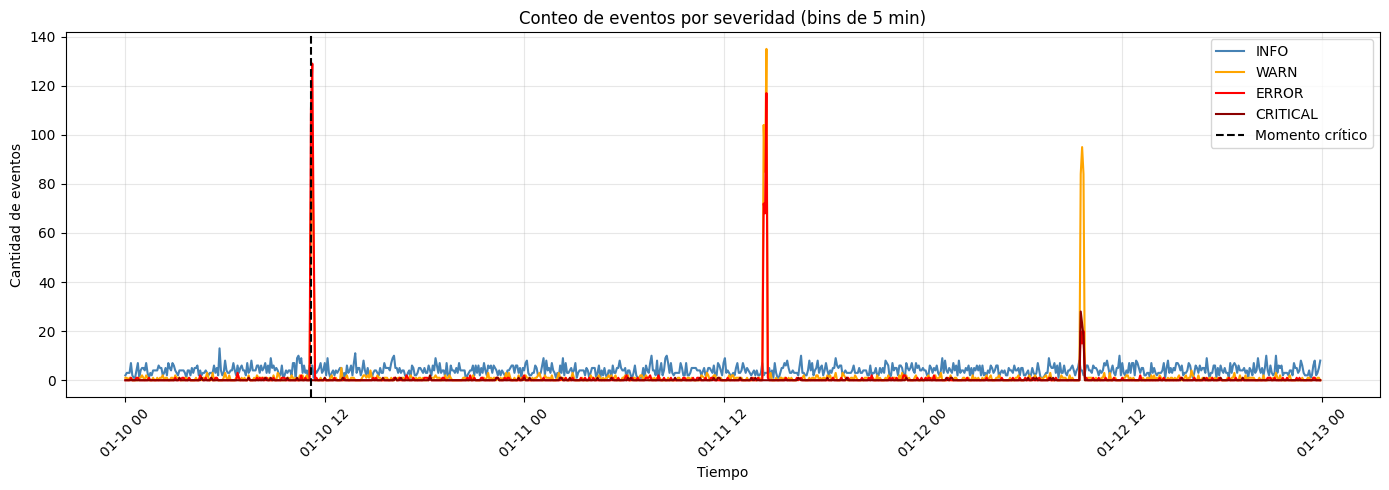

In [268]:
import matplotlib.pyplot as plt

# ── Gráfico 1: Conteo de eventos por severidad en bins de 5 min ──

df_sev = (
    df.groupby([pd.Grouper(key='timestamp_event', freq='5min'), 'severity'])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 5))

colores = {
    'INFO': 'steelblue',
    'WARN': 'orange',
    'ERROR': 'red',
    'CRITICAL': 'darkred'
}

for severidad in ['INFO', 'WARN', 'ERROR', 'CRITICAL']:
    if severidad in df_sev.columns:
        ax.plot(
            df_sev['timestamp_event'],
            df_sev[severidad],
            label=severidad,
            color=colores[severidad]
        )

ax.axvline(x=inicio_ventana, color='black', linestyle='--', linewidth=1.5, label='Momento crítico')

ax.set_title('Conteo de eventos por severidad (bins de 5 min)')
ax.set_xlabel('Tiempo')
ax.set_ylabel('Cantidad de eventos')
ax.legend()
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



### Grafico 2
bad_rate o %_5xx en bins de 5 min.

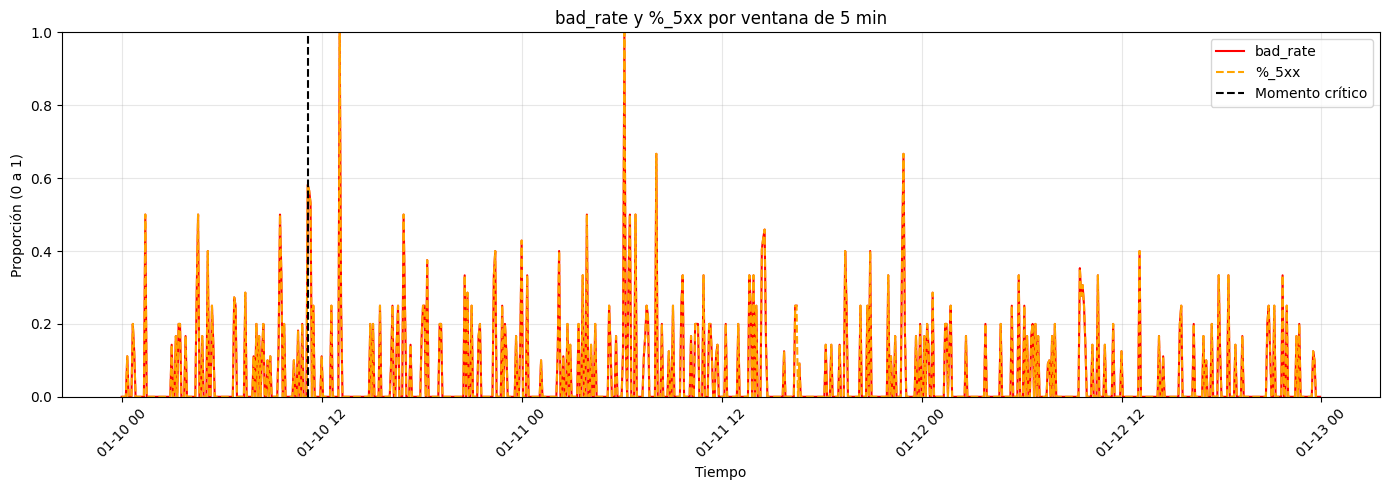

In [270]:
# ── Gráfico 2: bad_rate y %_5xx en bins de 5 min ──

df_rates = tabla_eventos[['timestamp_event', 'bad_rate']].copy()
df_rates['pct_5xx'] = (
    df.groupby(pd.Grouper(key='timestamp_event', freq='5min'))
    .apply(lambda x: (x['status_code'] >= 500).sum() / len(x) if len(x) > 0 else 0)
    .values
)
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    df_rates['timestamp_event'],
    df_rates['bad_rate'],
    label='bad_rate',
    color='red'
)

ax.plot(
    df_rates['timestamp_event'],
    df_rates['pct_5xx'],
    label='%_5xx',
    color='orange',
    linestyle='--'
)

ax.axvline(x=inicio_ventana, color='black', linestyle='--', linewidth=1.5, label='Momento crítico')

ax.set_title('bad_rate y %_5xx por ventana de 5 min')
ax.set_xlabel('Tiempo')
ax.set_ylabel('Proporción (0 a 1)')
ax.set_ylim(0, 1)
ax.legend()
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()